In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def RK4(g,x0,t):
    h = t[1]-t[0]
    sol = np.zeros( (len(x0),len(t)) )
    sol[:,0] = x0
    for i in range(len(t)-1):
        k1 = g(sol[:,i],t[i])
        k2 = g(sol[:,i]+0.5*k1*h,t[i]+0.5*h)
        k3 = g(sol[:,i]+0.5*k2*h,t[i]+0.5*h)
        k4 = g(sol[:,i]+k3*h,t[i]+h)
        sol[:,i+1] = sol[:,i] + h*(k1 + 2*k2 + 2*k3 + k4)/6
    return sol

In [3]:
def Sist_solar(x_v,t):
     #x_v= (x,y,vx,vy)
    dx, dy =x_v[2], x_v[3]
    r32 =(x_v[0]**2 + x_v[1]**2)**1.5
    dvx, dvy =-x_v[0]/r32, -x_v[1]/r32
    return np.array([dx,dy,dvx,dvy])

In [4]:
ci = np.array([1,0,0,1])
t = np.arange(0, 50*np.pi, 0.005)
#t = np.arange(0,2*np.pi,0.01) esto es solo un año
x_v = RK4(Sist_solar, ci, t)

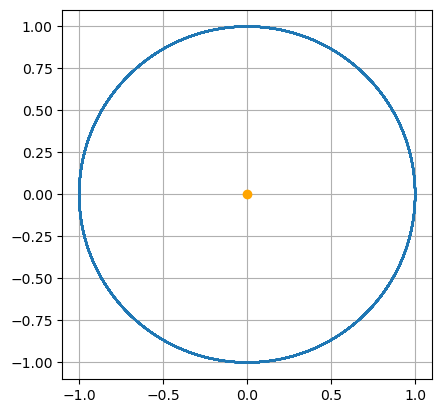

(None, None)

In [5]:
plt.plot(x_v[0,:], x_v[1,:])
plt.gca().set_aspect('equal')
plt.plot([0],[0],'o', color='orange')
plt.grid(), plt.show()

t_final =  314.16
t_final =  314.16
Diferencia 1.0413246931406661e-09


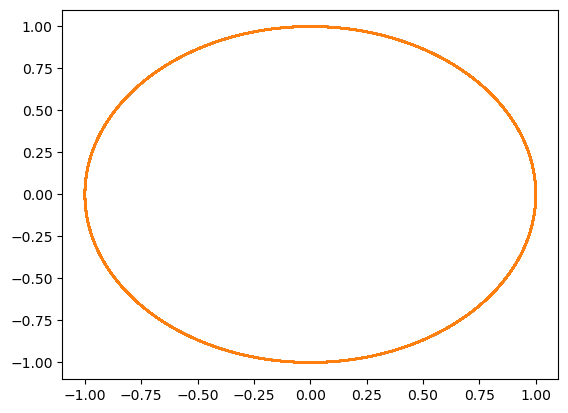

In [6]:
ci = np.array([ 1 , 0 , 0 , 1 ])
delta = 0.005
t = np.arange(0,100*np.pi+delta,delta)
print('t_final = ',t[-1])
x_v1 = RK4(Sist_solar,ci,t)
delta = 0.01
t = np.arange(0,100*np.pi+delta,0.01)
print('t_final = ',t[-1])
x_v2 = RK4(Sist_solar,ci,t)
print('Diferencia', abs(x_v1[0,-1]-x_v2[0,-1] ))
plt.plot(x_v1[0,:],x_v1[1,:])
plt.plot(x_v2[0,:],x_v2[1,:])
plt.show()

In [10]:
delta = 0.1
t = np.arange(0,100*np.pi+delta,delta)
x_v = RK4(Sist_solar,ci,t)
pto_ref = x_v[0,-1]
print(delta,t[-1],pto_ref)
for i in range(8):
    delta = delta+10
    t = np.arange(0,100+delta,delta)
    x_v = RK4(Sist_solar,ci,t)
    deltas[i] = delta
    errores[i] = abs(pt_ref-x_v[0,-1])
    pto_ref = x_v[0,-1]
    print(delta,t[-1],pto_ref)

0.1 314.20000000000005 0.9979873119327148


NameError: name 'deltas' is not defined

In [9]:
plt.semilogy(delta, errores, '+-')
plt.show()

NameError: name 'deltas' is not defined

In [ ]:
#una forma de revisar si los algoritmos esta bien, 
#es viendo si es reversible